In [ ]:
from google.colab import files

uploaded = files.upload()


Saving y_train.csv to y_train (1).csv
Saving X_train_scaled.csv to X_train_scaled (1).csv
Saving y_test.csv to y_test (1).csv
Saving X_test_scaled.csv to X_test_scaled (1).csv


In [ ]:
import pandas as pd

X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')

y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Results
MAE : 11557.30
RMSE: 28065.93
R²  : 0.9886


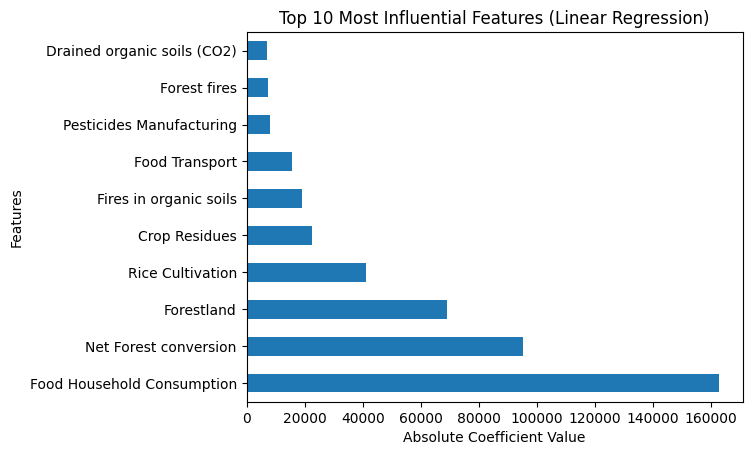

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

coefficients = pd.Series(lr.coef_, index=X_train.columns)

coefficients.abs().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Most Influential Features (Linear Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Features')
plt.show()

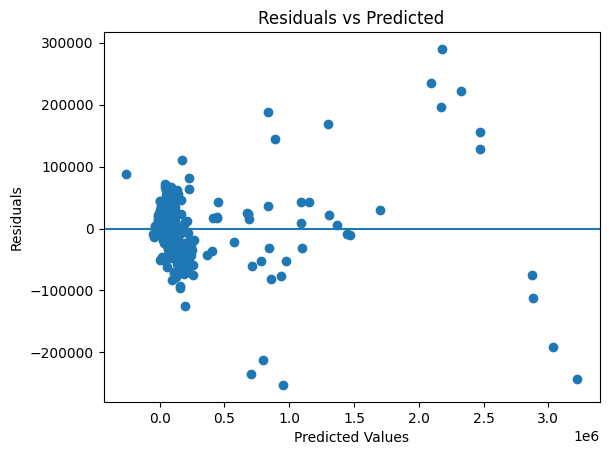

In [ ]:
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print(f"MAE : {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²  : {r2_ridge:.4f}")

Ridge Regression Results
MAE : 11549.46
RMSE: 28056.40
R²  : 0.9886


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [ ]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print(f"MAE : {mae_lasso:.2f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"R²  : {r2_lasso:.4f}")

Lasso Regression Results
MAE : 11557.30
RMSE: 28065.93
R²  : 0.9886


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest Results
MAE : 3385.84
RMSE: 22355.65
R²  : 0.9928


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Random Forest'
    ],
    'MAE': [
        11557.30,
        mae_ridge,
        mae_lasso,
        mae_rf
    ],
    'RMSE': [
        28065.93,
        rmse_ridge,
        rmse_lasso,
        rmse_rf
    ],
    'R2': [
        0.9886,
        r2_ridge,
        r2_lasso,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,11557.300000,28065.930000,0.988600
1,Ridge Regression,11549.459551,28056.404990,0.988620
2,Lasso Regression,11557.298735,28065.926191,0.988613
3,Random Forest,3385.837913,22355.646311,0.992775


In [ ]:
import joblib
joblib.dump(ridge, 'final_ridge_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']